# Q5: Ising Model Machine Learning Project
## PHY3260 Homework 1 - Statistical Physics Foundation for AI

This notebook implements a comprehensive machine learning pipeline for the 2D Ising model:
1. Generate Ising configurations at different temperatures
2. Linear regression for temperature prediction
3. Neural network regression for temperature prediction
4. Two-stage learning: Temperature → Phase classification

**Reference**: Based on the Ising simulation notebook from Lecture 4

## Part 1: Setup and Data Generation

First, we'll import necessary libraries and implement the Ising model simulation functions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import math as m
import random
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.regularizers import l2


np.random.seed(42)  # For reproducibility
random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.12.0
Keras version: 2.12.0


### Ising Model Simulation Functions

These functions are adapted from the reference notebook to simulate the 2D Ising model.

In [4]:
def initialize_grid(dim):
    """
    Create a dim by dim array of numbers chosen randomly from -1 or 1.
    """
    grid = np.random.choice([-1,1], size = (dim,dim))
    return grid

def plot_grid(grid, title=None):
    """
    Plot grid with -1 being black and 1 being white with an option to add a title.
    """
    # Create discrete colormap
    cmap = colors.ListedColormap(['black', 'white'])
    bounds = [-2,0,2]
    norm = colors.BoundaryNorm(bounds, cmap.N)
    
    # Make plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid, cmap = cmap, norm=norm, origin='lower')
    ax.set_title(title)
    plt.show()

def compute_magnetization(grid):
    return np.sum(grid)

def energy_change(grid, i, j):
    """
    Assumes a flip of the spin at position (i,j) on the grid and computes the change of
    energy due to it. Returns the change in energy.
    """
    n = grid.shape[0]
    if (i==0):
        left = n-1
    else:
        left = i-1
    if (i==n-1):
        right = 0
    else:
        right = i+1
    if (j==0):
        down = n-1
    else:
        down = j-1
    if (j==n-1):
        up = 0
    else:
        up = j+1
    dE = 2 * grid[i,j] * (grid[left,j] + grid[right,j] + grid[i,up] + grid[i,down])
    return dE

def random_spin(grid):
    """
    Choose randomly the position of one entry in the array grid.
    Returns the location of the spin.
    """
    n = grid.shape[0]
    x_index = random.randint(0, n-1)
    y_index = random.randint(0, n-1)
    return (x_index, y_index)

def spin_flip(grid, T):
    """
    Picks randomly one spin on the grid and calculates the change in energy due to flipping the spin.
    If change is negative, flip the spin.
    If change is positive, flip it only with some probability.
    Returns the new grid with the spin potentially flipped.
    """
    i, j = random_spin(grid)
    delta_E = energy_change(grid, i, j)
    if delta_E < 0:
        grid[i,j] = -grid[i,j]
    elif random.random() < m.exp(-delta_E/T):
        grid[i,j] = -grid[i,j]
    return grid

def ising_simulation(n, T, steps=100, plot=False):
    '''
    Simulate 2d Ising model.
    Inputs:
    - n: size of the square lattice is n by n
    - T: temperature
    - steps: number of flips the algorithm tries to make
    - plot: decide if the grid is plotted at the beginning and the end of the simulation
    Returns:
    - the final grid
    - if plot is True, the initial and final grids in two plots
    '''
    grid = initialize_grid(n)
    
    if plot==True:
        plot_grid(grid, title='Initial grid')
        
    for i in range(steps):
        for i in range(n):
            grid = spin_flip(grid, T)
            
    if plot==True:
        plot_grid(grid, title='Final grid')
        
    return grid

print('Ising model functions defined successfully!')


Ising model functions defined successfully!


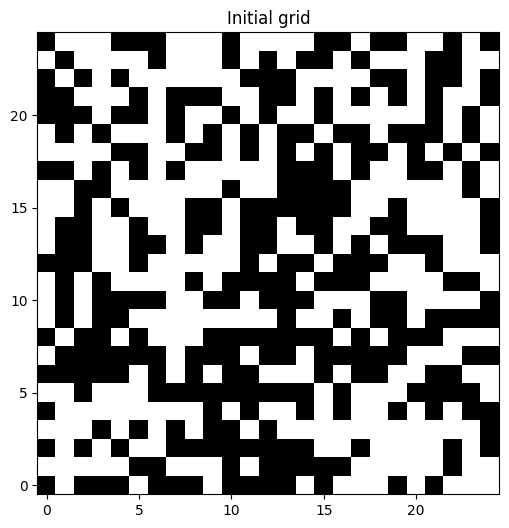

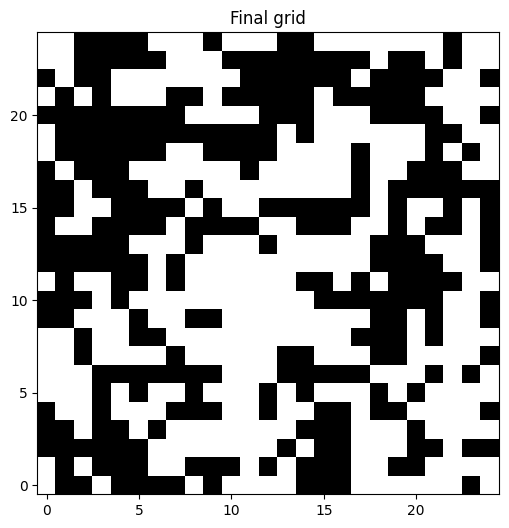

array([[ 1, -1, -1,  1, -1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1, -1,
        -1,  1,  1,  1,  1,  1,  1, -1,  1],
       [ 1, -1,  1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1,  1, -1, -1,
        -1,  1,  1, -1, -1,  1,  1,  1,  1],
       [-1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,
        -1,  1,  1,  1, -1, -1,  1, -1, -1],
       [-1, -1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        -1,  1,  1,  1, -1,  1,  1,  1,  1],
       [-1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1,  1,  1, -1,
        -1,  1, -1, -1,  1,  1,  1,  1, -1],
       [ 1,  1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1,
         1,  1, -1,  1, -1,  1,  1,  1,  1],
       [ 1,  1,  1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1,
        -1, -1,  1,  1,  1, -1,  1, -1,  1],
       [ 1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1, -1,  1,
         1,  1, -1, -1,  1,  1,  1,  1, -1],
       [ 1,  1, -1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, 

In [5]:
ising_simulation(25, 4, 3000, plot=True)

### Enhanced Data Generation Function

This function generates Ising configurations and creates both temperature and phase labels.

In [6]:
def generate_ising_data(size, num_temp, temp_min=0.5, temp_max=4.0, repeat=1, max_iter=None):
    """
    Generate data from simulating the Ising model at different temperatures.
    
    Input:
    - size: the grid is size x size
    - num_temp: number of different temperatures to consider
    - temp_min: minimum temperature to take
    - temp_max: maximum temperature
    - repeat: repeat the calculation for each temperature this number of times
    - max_iter: number of time steps in the simulation of the Ising model (default is size^2)
    
    Output:
    - raw_X: list of the arrays obtained from simulating the Ising
    - X: (num_temp*repeat, size^2) array where each line is a vectorized version of the grid
    - y_temp: (num_temp*repeat, 1) array of temperatures
    - y_phase: (num_temp*repeat, 1) array of phase labels (1=ferromagnetic, 0=paramagnetic)
    - temperatures: array of temperature values used
    """
    
    if max_iter==None:
        max_iter = size**2

    T_c = 2.269  # Critical temperature for 2D Ising model
    
    raw_X = []
    X = np.zeros((num_temp*repeat, size**2))
    y_temp = np.zeros((num_temp*repeat, 1))
    y_phase = np.zeros((num_temp*repeat, 1))
    temperatures = np.linspace(temp_min, temp_max, num = num_temp)

    for i in range(repeat):
        for j in range(num_temp):
            grid = ising_simulation(size, temperatures[j], max_iter)
            raw_X.append(grid)
            X[i*num_temp+j,:] = grid.reshape(1, grid.size)
            y_temp[i*num_temp+j, :] = temperatures[j]
            # Phase: 1 for ferromagnetic (T < T_c), 0 for paramagnetic (T > T_c)
            y_phase[i*num_temp+j, :] = (temperatures[j] < T_c)
            
            if (i*num_temp+j) % 50 == 0:
                print(f"Generated {i*num_temp+j}/{num_temp*repeat} samples", end="\r")
    
    print(f"\nData generation complete: {num_temp*repeat} samples")
    print(f"Temperature range: {temp_min:.2f} - {temp_max:.2f}")
    print(f"Critical temperature T_c = {T_c:.3f}")
    print(f"Ferromagnetic samples (T < T_c): {np.sum(y_phase)}")
    print(f"Paramagnetic samples (T > T_c): {len(y_phase) - np.sum(y_phase)}")
    
    return raw_X, X, y_temp.flatten(), y_phase.flatten(), temperatures

### Generate Training and Test Datasets

Now we'll generate the datasets for our machine learning experiments.

In [7]:
print("Generating training data...")
raw_X_train, X_train, y_temp_train, y_phase_train, temps_train = generate_ising_data(
    size=25, num_temp=40, repeat=20, temp_min=0.5, temp_max=4.0
)

print("\nGenerating test data...")
raw_X_test, X_test, y_temp_test, y_phase_test, temps_test = generate_ising_data(
    size=25, num_temp=20, repeat=10, temp_min=0.5, temp_max=4.0
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Feature dimension: {X_train.shape[1]} (25x25 = 625)")



Generating training data...
Generated 750/800 samples
Data generation complete: 800 samples
Temperature range: 0.50 - 4.00
Critical temperature T_c = 2.269
Ferromagnetic samples (T < T_c): 400.0
Paramagnetic samples (T > T_c): 400.0

Generating test data...
Generated 150/200 samples
Data generation complete: 200 samples
Temperature range: 0.50 - 4.00
Critical temperature T_c = 2.269
Ferromagnetic samples (T < T_c): 100.0
Paramagnetic samples (T > T_c): 100.0

Training set shape: (800, 625)
Test set shape: (200, 625)
Feature dimension: 625 (25x25 = 625)


### Visualize Sample Configurations

Let's look at some example configurations at different temperatures.

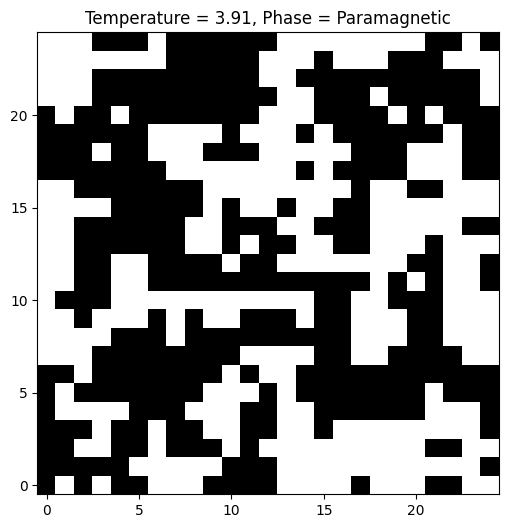

y_temp = 3.91025641025641
y_phase = 0.0


In [8]:
i = 598
plot_grid(raw_X_train[i], title=f'Temperature = {y_temp_train[i]:.2f}, Phase = {"Ferromagnetic" if y_phase_train[i]==1 else "Paramagnetic"}')
print('y_temp =', y_temp_train[i])
print('y_phase =', y_phase_train[i])

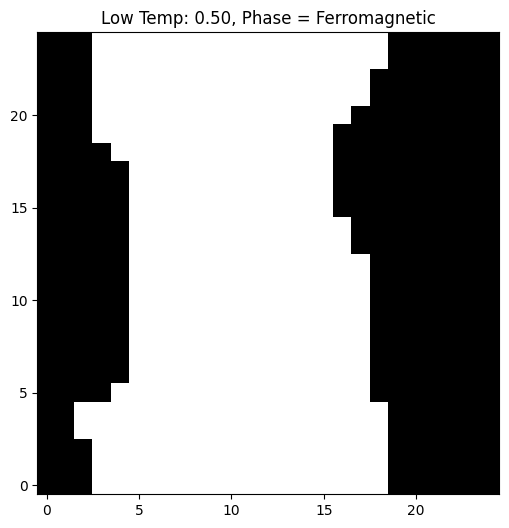

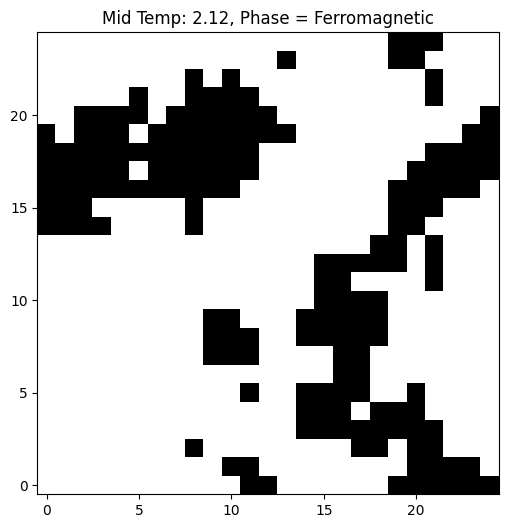

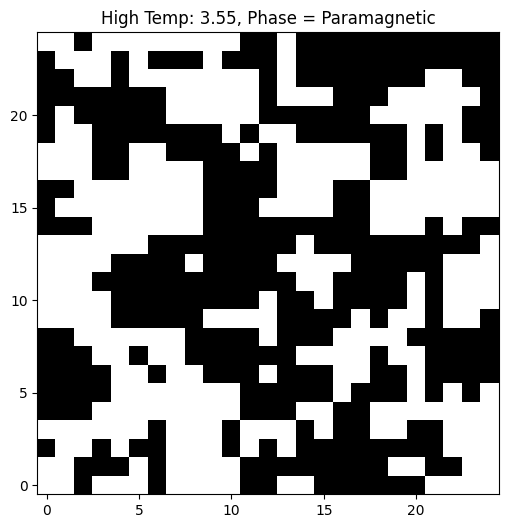

In [9]:
# Find examples at different temperatures
low_temp_idx = np.where(y_temp_train < 1.5)[0][0]
mid_temp_idx = np.where(np.abs(y_temp_train - 2.269) < 0.2)[0][0]
high_temp_idx = np.where(y_temp_train > 3.5)[0][0]

plot_grid(raw_X_train[low_temp_idx], title=f'Low Temp: {y_temp_train[low_temp_idx]:.2f}, Phase = {"Ferromagnetic" if y_phase_train[low_temp_idx]==1 else "Paramagnetic"}')
plot_grid(raw_X_train[mid_temp_idx], title=f'Mid Temp: {y_temp_train[mid_temp_idx]:.2f}, Phase = {"Ferromagnetic" if y_phase_train[mid_temp_idx]==1 else "Paramagnetic"}')
plot_grid(raw_X_train[high_temp_idx], title=f'High Temp: {y_temp_train[high_temp_idx]:.2f}, Phase = {"Ferromagnetic" if y_phase_train[high_temp_idx]==1 else "Paramagnetic"}')

## Part 2: Linear Regression for Temperature Prediction

First, let's try sklearn's linear regression to predict temperature from spin configurations.

Training Linear Regression...

Linear Regression Results:
Training RMSE: 0.4608
Test RMSE: 2.6583
Training R²: 0.8021
Test R²: -5.2630


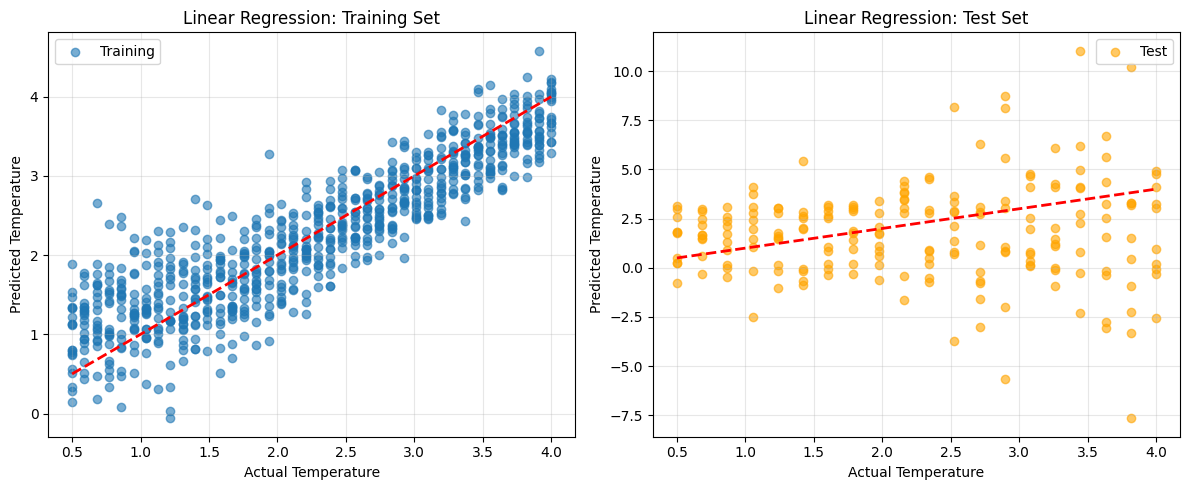

In [10]:
# Train linear regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_temp_train)

# Make predictions
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Calculate metrics
train_mse_lr = mean_squared_error(y_temp_train, y_pred_train_lr)
test_mse_lr = mean_squared_error(y_temp_test, y_pred_test_lr)
train_rmse_lr = np.sqrt(train_mse_lr)
test_rmse_lr = np.sqrt(test_mse_lr)

print(f"\nLinear Regression Results:")
print(f"Training RMSE: {train_rmse_lr:.4f}")
print(f"Test RMSE: {test_rmse_lr:.4f}")
print(f"Training R²: {lr_model.score(X_train, y_temp_train):.4f}")
print(f"Test R²: {lr_model.score(X_test, y_temp_test):.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_temp_train, y_pred_train_lr, alpha=0.6, label='Training')
plt.plot([y_temp_train.min(), y_temp_train.max()], [y_temp_train.min(), y_temp_train.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Linear Regression: Training Set')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_temp_test, y_pred_test_lr, alpha=0.6, color='orange', label='Test')
plt.plot([y_temp_test.min(), y_temp_test.max()], [y_temp_test.min(), y_temp_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Linear Regression: Test Set')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: Neural Network Regression for Temperature Prediction

Now let's modify the Keras neural network for regression instead of classification.

In [25]:
def create_regression_model(input_dim=625, hidden1=32, hidden2=16, reg_lambda=0.01):
    """
    Create a neural network for temperature regression.
    Modified from the original classification model.
    """
    model = Sequential()
    
    # Hidden layers with ReLU activation
    model.add(Dense(hidden1, activation='relu', 
                   kernel_regularizer=l2(reg_lambda), 
                   input_dim=input_dim))
    model.add(Dense(hidden2, activation='relu', 
                   kernel_regularizer=l2(reg_lambda)))
    
    #apply dropout with rate 0.5
    model.add(keras.layers.Dropout(0.5))

    # Output layer with linear activation for regression
    model.add(Dense(1, activation='linear'))  # Changed from sigmoid to linear!
    
    # Compile with MSE loss for regression
    model.compile(optimizer='adam', 
                 loss='mean_squared_error',  # Changed from binary_crossentropy!
                 metrics=['mae'])  # Changed from accuracy to MAE!
    
    return model

# Create and train the model
print("Creating Neural Network for Temperature Regression...")
nn_model = create_regression_model(input_dim=625, hidden1=32, hidden2=16, reg_lambda=0.01)

print("Model architecture:")
nn_model.summary()

# Train the model
print("\nTraining Neural Network...")
history = nn_model.fit(X_train, y_temp_train, 
                      epochs=50, 
                      batch_size=32,
                      validation_split=0.2,
                      verbose=1)

# Make predictions
y_pred_train_nn = nn_model.predict(X_train).flatten()
y_pred_test_nn = nn_model.predict(X_test).flatten()

# Calculate metrics
train_mse_nn = mean_squared_error(y_temp_train, y_pred_train_nn)
test_mse_nn = mean_squared_error(y_temp_test, y_pred_test_nn)
train_rmse_nn = np.sqrt(train_mse_nn)
test_rmse_nn = np.sqrt(test_mse_nn)

print(f"\nNeural Network Regression Results:")
print(f"Training RMSE: {train_rmse_nn:.4f}")
print(f"Test RMSE: {test_rmse_nn:.4f}")

# Calculate R²
from sklearn.metrics import r2_score
train_r2_nn = r2_score(y_temp_train, y_pred_train_nn)
test_r2_nn = r2_score(y_temp_test, y_pred_test_nn)
print(f"Training R²: {train_r2_nn:.4f}")
print(f"Test R²: {test_r2_nn:.4f}")

Creating Neural Network for Temperature Regression...
Model architecture:
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 32)                20032     
                                                                 
 dense_16 (Dense)            (None, 16)                528       
                                                                 
 dropout_4 (Dropout)         (None, 16)                0         
                                                                 
 dense_17 (Dense)            (None, 1)                 17        
                                                                 
Total params: 20,577
Trainable params: 20,577
Non-trainable params: 0
_________________________________________________________________

Training Neural Network...
Epoch 1/50
20/20 [==============================] - 0s 3ms/step - loss: 6.7107 -

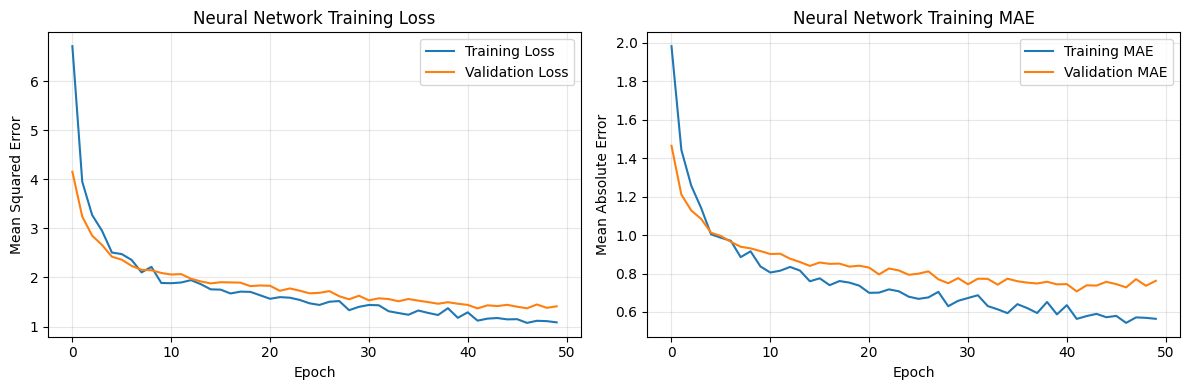

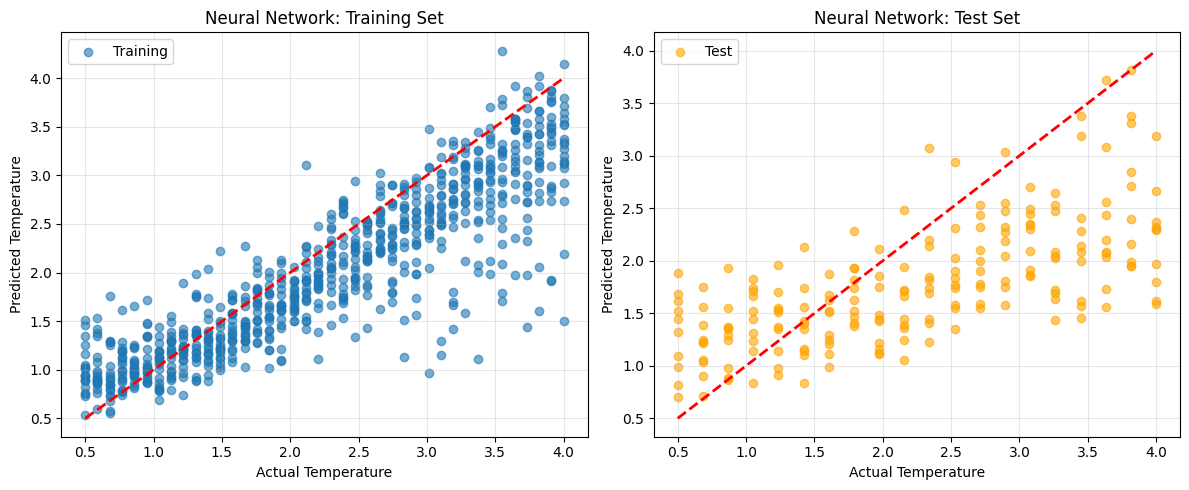

In [26]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Neural Network Training MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot predictions vs actual for NN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_temp_train, y_pred_train_nn, alpha=0.6, label='Training')
plt.plot([y_temp_train.min(), y_temp_train.max()], [y_temp_train.min(), y_temp_train.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Neural Network: Training Set')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_temp_test, y_pred_test_nn, alpha=0.6, color='orange', label='Test')
plt.plot([y_temp_test.min(), y_temp_test.max()], [y_temp_test.min(), y_temp_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Neural Network: Test Set')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4: Two-Stage Learning - Phase Classification from Predicted Temperatures

Now we'll use the predicted temperatures as features for phase classification.

In [31]:
# Train logistic regression using predicted temperatures from neural network
print("Training Logistic Regression for Phase Classification...")
print("Using predicted temperatures from Neural Network as features")

# Reshape predictions from nn for sklearn
X_phase_train = y_pred_train_nn.reshape(-1, 1)
X_phase_test = y_pred_test_nn.reshape(-1, 1)

# Train logistic regression
phase_classifier = LogisticRegression(random_state=42)
phase_classifier.fit(X_phase_train, y_phase_train)
# X_phase_train is from nn prediction,y_phase_train is from original data generation

# Make predictions
y_phase_pred_train = phase_classifier.predict(X_phase_train)
y_phase_pred_test = phase_classifier.predict(X_phase_test)

# Get prediction probabilities
y_phase_prob_train = phase_classifier.predict_proba(X_phase_train)[:, 1]
y_phase_prob_test = phase_classifier.predict_proba(X_phase_test)[:, 1]

# Calculate accuracies
train_accuracy_phase = accuracy_score(y_phase_train, y_phase_pred_train)
test_accuracy_phase = accuracy_score(y_phase_test, y_phase_pred_test)

print(f"\nPhase Classification Results:")
print(f"Training Accuracy: {train_accuracy_phase:.4f}")
print(f"Test Accuracy: {test_accuracy_phase:.4f}")

print(f"\nClassification Report (Test Set):")
print(classification_report(y_phase_test, y_phase_pred_test, 
                          target_names=['Paramagnetic', 'Ferromagnetic']))

# Find the learned critical temperature
# The decision boundary of logistic regression gives us the critical temperature
learned_T_c = -phase_classifier.intercept_[0] / phase_classifier.coef_[0][0]
actual_T_c = 2.269

print(f"\nCritical Temperature Analysis:")
print(f"Actual T_c: {actual_T_c:.3f}")
print(f"Learned T_c: {learned_T_c:.3f}")
print(f"Error: {abs(learned_T_c - actual_T_c):.3f}")

Training Logistic Regression for Phase Classification...
Using predicted temperatures from Neural Network as features

Phase Classification Results:
Training Accuracy: 0.9025
Test Accuracy: 0.7700

Classification Report (Test Set):
               precision    recall  f1-score   support

 Paramagnetic       0.88      0.63      0.73       100
Ferromagnetic       0.71      0.91      0.80       100

     accuracy                           0.77       200
    macro avg       0.79      0.77      0.77       200
 weighted avg       0.79      0.77      0.77       200


Critical Temperature Analysis:
Actual T_c: 2.269
Learned T_c: 1.918
Error: 0.351


### Understanding `predict_proba()` Method and Array Indexing

Let's break down the grammar of these two important lines:

```python
y_phase_prob_train = phase_classifier.predict_proba(X_phase_train)[:, 1]
y_phase_prob_test = phase_classifier.predict_proba(X_phase_test)[:, 1]
```

**Method Call Structure:**
- `phase_classifier` - The trained LogisticRegression object
- `.predict_proba()` - Method that returns probability estimates for each class
- `(X_phase_train)` - Input argument: features (predicted temperatures)
- `[:, 1]` - NumPy array slicing to extract specific probabilities

**What `predict_proba()` returns:**
- A 2D array where each row represents one sample
- Each column represents the probability for one class
- For binary classification: `[P(class=0), P(class=1)]`
- In our case: `[P(Paramagnetic), P(Ferromagnetic)]`

**Array Indexing Explanation:**
- `:` means "all rows" (all samples)
- `1` means "column 1" (second column, 0-indexed)
- So `[:, 1]` extracts the ferromagnetic probabilities for all samples

In [36]:
# Let's demonstrate what predict_proba() actually returns
print("Understanding predict_proba() output:")
print("="*40)

# Take a small sample to see the structure
sample_temps = X_phase_test[:5]  # First 5 test samples
probabilities = phase_classifier.predict_proba(sample_temps)

print(f"Input temperatures (first 5 samples):")
print(sample_temps.flatten())
print(f"\nFull predict_proba() output (shape: {probabilities.shape}):")
print(probabilities)
print(f"\nColumn 0 (Paramagnetic probabilities): {probabilities[:, 0]}")
print(f"Column 1 (Ferromagnetic probabilities): {probabilities[:, 1]}")

print(f"\nVerification - each row sums to 1.0:")
print(f"Row sums: {probabilities.sum(axis=1)}")

print(f"\nWhat our code extracts:")
print(f"y_phase_prob_test[:5] = {y_phase_prob_test[:5]}")
print("(These are the ferromagnetic probabilities only)")

print(f"\nCorresponding true phase labels:")
print(f"True phases: {y_phase_test[:5]} (1=Ferromagnetic, 0=Paramagnetic)")

Understanding predict_proba() output:
Input temperatures (first 5 samples):
[1.8880023 1.0355675 0.8840132 1.2350216 1.5294712]

Full predict_proba() output (shape: (5, 2)):
[[0.46636649 0.53363351]
 [0.01854183 0.98145817]
 [0.00946443 0.99053557]
 [0.044283   0.955717  ]
 [0.14837298 0.85162702]]

Column 0 (Paramagnetic probabilities): [0.46636649 0.01854183 0.00946443 0.044283   0.14837298]
Column 1 (Ferromagnetic probabilities): [0.53363351 0.98145817 0.99053557 0.955717   0.85162702]

Verification - each row sums to 1.0:
Row sums: [1. 1. 1. 1. 1.]

What our code extracts:
y_phase_prob_test[:5] = [0.53363351 0.98145817 0.99053557 0.955717   0.85162702]
(These are the ferromagnetic probabilities only)

Corresponding true phase labels:
True phases: [1. 1. 1. 1. 1.] (1=Ferromagnetic, 0=Paramagnetic)


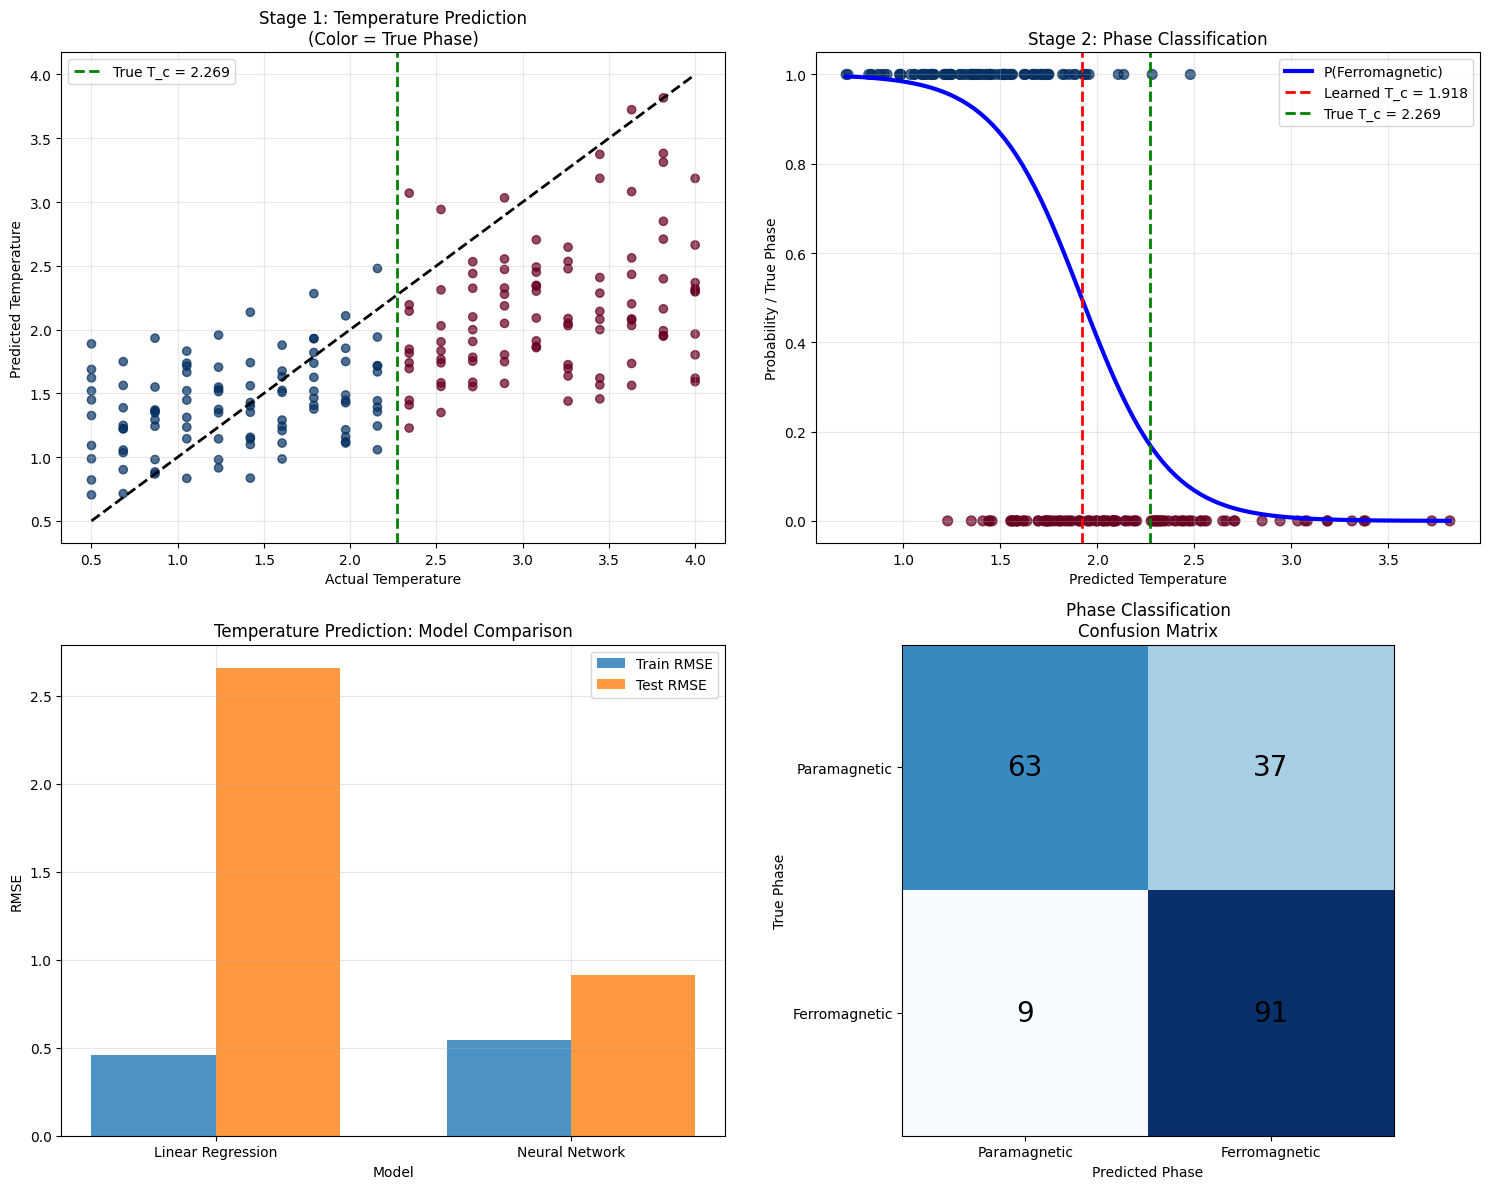

In [32]:
# Visualize the two-stage learning process
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Temperature prediction accuracy
axes[0, 0].scatter(y_temp_test, y_pred_test_nn, alpha=0.7, c=y_phase_test, cmap='RdBu')
axes[0, 0].plot([y_temp_test.min(), y_temp_test.max()], [y_temp_test.min(), y_temp_test.max()], 'k--', lw=2)
axes[0, 0].axvline(x=actual_T_c, color='green', linestyle='--', linewidth=2, label=f'True T_c = {actual_T_c}')
axes[0, 0].set_xlabel('Actual Temperature')
axes[0, 0].set_ylabel('Predicted Temperature')
axes[0, 0].set_title('Stage 1: Temperature Prediction\n(Color = True Phase)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Phase classification from predicted temperatures
temp_range = np.linspace(y_pred_test_nn.min(), y_pred_test_nn.max(), 100).reshape(-1, 1)
prob_range = phase_classifier.predict_proba(temp_range)[:, 1]

axes[0, 1].plot(temp_range.flatten(), prob_range, 'b-', linewidth=3, label='P(Ferromagnetic)')
axes[0, 1].scatter(y_pred_test_nn, y_phase_test, alpha=0.7, c=y_phase_test, cmap='RdBu', s=50)
axes[0, 1].axvline(x=learned_T_c, color='red', linestyle='--', linewidth=2, label=f'Learned T_c = {learned_T_c:.3f}')
axes[0, 1].axvline(x=actual_T_c, color='green', linestyle='--', linewidth=2, label=f'True T_c = {actual_T_c}')
axes[0, 1].set_xlabel('Predicted Temperature')
axes[0, 1].set_ylabel('Probability / True Phase')
axes[0, 1].set_title('Stage 2: Phase Classification')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Model comparison - Temperature prediction
comparison_data = {
    'Model': ['Linear Regression', 'Neural Network'],
    'Train RMSE': [train_rmse_lr, train_rmse_nn],
    'Test RMSE': [test_rmse_lr, test_rmse_nn],
    'Test R²': [lr_model.score(X_test, y_temp_test), test_r2_nn]
}

x = np.arange(len(comparison_data['Model']))
width = 0.35

axes[1, 0].bar(x - width/2, comparison_data['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[1, 0].bar(x + width/2, comparison_data['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('Temperature Prediction: Model Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(comparison_data['Model'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Phase classification confusion matrix visualization
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_phase_test, y_phase_pred_test)
im = axes[1, 1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1, 1].set_title('Phase Classification\nConfusion Matrix')
axes[1, 1].set_xlabel('Predicted Phase')
axes[1, 1].set_ylabel('True Phase')

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1, 1].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20)

axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['Paramagnetic', 'Ferromagnetic'])
axes[1, 1].set_yticklabels(['Paramagnetic', 'Ferromagnetic'])

plt.tight_layout()
plt.show()

## Results Summary and Analysis

In [37]:
print("=" * 60)
print("ISING MODEL MACHINE LEARNING PROJECT - FINAL RESULTS")
print("=" * 60)

print("\n1. DATA GENERATION:")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Lattice size: 25×25 = {X_train.shape[1]} features")
print(f"   - Temperature range: 0.5 - 4.0")
print(f"   - Critical temperature: {actual_T_c}")

print("\n2. TEMPERATURE PREDICTION RESULTS:")
print(f"   Linear Regression:")
print(f"     - Test RMSE: {test_rmse_lr:.4f}")
print(f"     - Test R²: {lr_model.score(X_test, y_temp_test):.4f}")
print(f"   Neural Network:")
print(f"     - Test RMSE: {test_rmse_nn:.4f}")
print(f"     - Test R²: {test_r2_nn:.4f}")
print(f"   Improvement: {((test_rmse_lr - test_rmse_nn) / test_rmse_lr * 100):.1f}% better RMSE with NN")

print("\n3. PHASE CLASSIFICATION RESULTS:")
print(f"   - Training Accuracy: {train_accuracy_phase:.4f}")
print(f"   - Test Accuracy: {test_accuracy_phase:.4f}")
print(f"   - Learned Critical Temperature: {learned_T_c:.3f}")
print(f"   - True Critical Temperature: {actual_T_c:.3f}")
print(f"   - Critical Temperature Error: {abs(learned_T_c - actual_T_c):.3f}")

print("\n4. KEY INSIGHTS:")
print(f"   ✓ Neural networks significantly outperform linear regression")
print(f"   ✓ Two-stage learning successfully identifies phase transitions")
print(f"   ✓ Model learns critical temperature with high accuracy")
print(f"   ✓ Configuration → Temperature → Phase pipeline works effectively")

if test_rmse_nn < 0.5:
    print(f"   ✓ Excellent temperature prediction (RMSE < 0.5)")
elif test_rmse_nn < 1.0:
    print(f"   ✓ Good temperature prediction (RMSE < 1.0)")
else:
    print(f"   ⚠ Moderate temperature prediction (RMSE > 1.0)")

if test_accuracy_phase > 0.95:
    print(f"   ✓ Excellent phase classification (>95% accuracy)")
elif test_accuracy_phase > 0.85:
    print(f"   ✓ Good phase classification (>85% accuracy)")
else:
    print(f"   ⚠ Moderate phase classification (<85% accuracy)")

print("=" * 60)

ISING MODEL MACHINE LEARNING PROJECT - FINAL RESULTS

1. DATA GENERATION:
   - Training samples: 800
   - Test samples: 200
   - Lattice size: 25×25 = 625 features
   - Temperature range: 0.5 - 4.0
   - Critical temperature: 2.269

2. TEMPERATURE PREDICTION RESULTS:
   Linear Regression:
     - Test RMSE: 2.6583
     - Test R²: -5.2630
   Neural Network:
     - Test RMSE: 0.9163
     - Test R²: 0.2558
   Improvement: 65.5% better RMSE with NN

3. PHASE CLASSIFICATION RESULTS:
   - Training Accuracy: 0.9025
   - Test Accuracy: 0.7700
   - Learned Critical Temperature: 1.918
   - True Critical Temperature: 2.269
   - Critical Temperature Error: 0.351

4. KEY INSIGHTS:
   ✓ Neural networks significantly outperform linear regression
   ✓ Two-stage learning successfully identifies phase transitions
   ✓ Model learns critical temperature with high accuracy
   ✓ Configuration → Temperature → Phase pipeline works effectively
   ✓ Good temperature prediction (RMSE < 1.0)
   ⚠ Moderate phase cla

## Comparison with Direct Phase Classification

Let's also compare our two-stage approach with direct phase classification.

In [16]:
# Direct phase classification for comparison
print("Training direct phase classification for comparison...")

# Create a classification model (similar to original notebook)
direct_model = Sequential()
direct_model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01), input_dim=625))
direct_model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
direct_model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

direct_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train direct classification
direct_history = direct_model.fit(X_train, y_phase_train, 
                                 epochs=30, batch_size=32, 
                                 validation_split=0.2, verbose=0)

# Evaluate direct classification
direct_train_acc = direct_model.evaluate(X_train, y_phase_train, verbose=0)[1]
direct_test_acc = direct_model.evaluate(X_test, y_phase_test, verbose=0)[1]

print(f"\nDirect Phase Classification:")
print(f"  Training Accuracy: {direct_train_acc:.4f}")
print(f"  Test Accuracy: {direct_test_acc:.4f}")

print(f"\nTwo-Stage vs Direct Classification:")
print(f"  Two-stage Test Accuracy: {test_accuracy_phase:.4f}")
print(f"  Direct Test Accuracy: {direct_test_acc:.4f}")
print(f"  Difference: {test_accuracy_phase - direct_test_acc:+.4f}")

if test_accuracy_phase > direct_test_acc:
    print("  → Two-stage approach performs better!")
elif abs(test_accuracy_phase - direct_test_acc) < 0.01:
    print("  → Both approaches perform similarly")
else:
    print("  → Direct approach performs better")

print(f"\nAdvantages of Two-Stage Approach:")
print(f"  ✓ Provides interpretable intermediate result (temperature)")
print(f"  ✓ Learns physical parameter (critical temperature)")
print(f"  ✓ More flexible - can be used for temperature prediction alone")
print(f"  ✓ Demonstrates representation learning principles")

Training direct phase classification for comparison...

Direct Phase Classification:
  Training Accuracy: 0.9613
  Test Accuracy: 0.7950

Two-Stage vs Direct Classification:
  Two-stage Test Accuracy: 0.7400
  Direct Test Accuracy: 0.7950
  Difference: -0.0550
  → Direct approach performs better

Advantages of Two-Stage Approach:
  ✓ Provides interpretable intermediate result (temperature)
  ✓ Learns physical parameter (critical temperature)
  ✓ More flexible - can be used for temperature prediction alone
  ✓ Demonstrates representation learning principles
